1. Train a deep MLP on the MNIST dataset, you can load it using keras.datasets.mnist.load_data(). 
- See if you can get over 98% precision. Try searching for the optimal learning rate (i.e., by growing the learning rate exponentially, plotting the error, and finding the point where the error shoots up), and plot learning curves using TensorBoard.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

2026-02-14 13:15:31.364975: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-14 13:15:31.386296: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-14 13:15:32.307561: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

Load and normalize image data 

In [3]:
GrayScale = 255

x_train = x_train.astype('float32') / GrayScale
x_test = x_test.astype('float32') / GrayScale

x_train = np.expand_dims(x_train, axis=-1)  # Shape becomes (60000, 28, 28, 1)
x_test = np.expand_dims(x_test, axis=-1)    # Shape becomes (10000, 28, 28, 1)
print(f"feature matrix x_train {x_train.shape}")
print(f"target matrix y:train {y_train.shape}")
print(f"feature matrix x_test {y_test.shape}")
print(f"target matrix y_test {y_test.shape}")

feature matrix x_train (60000, 28, 28, 1)
target matrix y:train (60000,)
feature matrix x_test (10000,)
target matrix y_test (10000,)


Some visualization

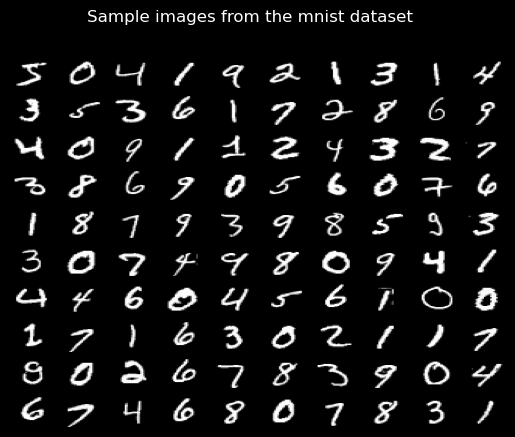

In [4]:
fig, ax = plt.subplots(10, 10)
k = 0
for i in range(10):
    for j in range(10):
        ax[i][j].imshow(x_train[k].reshape(28, 28), aspect='auto', cmap='gray')
        ax[i][j].axis('off')
        k += 1
fig.suptitle("Sample images from the mnist dataset")
plt.show()

Building the Neural network


In [5]:
model = Sequential(
    [
        Flatten(input_shape=(28, 28)),
        Dense(512, activation='relu'),
        Dropout(.3),
        Dense(256, activation='relu'),
        Dropout(.3),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax'),
    ]
)

model.summary()

/home/Nilse/.conda/envs/tf2/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
from tensorflow.keras.metrics import Precision
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),

              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

Eraly stop


In [7]:
from tensorflow.keras.callbacks import EarlyStopping

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# remove some channels
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)
datagen = ImageDataGenerator(
    rotation_range=10,       # Randomly rotate images by up to 10 degrees
    width_shift_range=0.1,   # Randomly shift images horizontally by 10% of the width
    height_shift_range=0.1,  # Randomly shift images vertically by 10% of the height
    zoom_range=0.1,          # Randomly zoom images by up to 10%
    shear_range=0.1,         # Shear transformations
    horizontal_flip=False,   # Set to True if horizontal flipping is relevant
    fill_mode='nearest'      # Fill in missing pixels after transformations
)

In [9]:

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Verify the shapes
print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)


In [10]:
datagen.fit(x_train)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True)

model.fit(datagen.flow(x_train, y_train, batch_size=32),
          epochs=100,
          validation_data=(x_test, y_test),
          callbacks=[early_stop])

Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8342 - loss: 0.5162 - val_accuracy: 0.9562 - val_loss: 0.1359
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9139 - loss: 0.2769 - val_accuracy: 0.9671 - val_loss: 0.1055
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9275 - loss: 0.2371 - val_accuracy: 0.9651 - val_loss: 0.1058
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9340 - loss: 0.2165 - val_accuracy: 0.9740 - val_loss: 0.0812
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9406 - loss: 0.1935 - val_accuracy: 0.9793 - val_loss: 0.0685
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9446 - loss: 0.1833 - val_accuracy: 0.9778 - val_loss: 0.0701
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9462 - loss: 0.1775 - val_accuracy: 0.9777 - val_loss: 0.0696
Epoch 8/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9489 - loss: 0

In [12]:
from sklearn.metrics import precision_score

In [13]:
results = model.evaluate(x_test, y_test, verbose=0)
print('Test loss, Test accuracy:', results)

Test loss, Test accuracy: [0.04857615754008293, 0.9861000180244446]


In [14]:
mod = model.fit(x_train, y_train, epochs=10,
                batch_size=2000,
                validation_split=0.2)

print(mod)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9759 - loss: 0.0823 - val_accuracy: 0.9876 - val_loss: 0.0383
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9776 - loss: 0.0749 - val_accuracy: 0.9887 - val_loss: 0.0368
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9797 - loss: 0.0677 - val_accuracy: 0.9891 - val_loss: 0.0359
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9797 - loss: 0.0656 - val_accuracy: 0.9890 - val_loss: 0.0353
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9807 - loss: 0.0615 - val_accuracy: 0.9891 - val_loss: 0.0347
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9814 - loss: 0.0599 - val_accuracy: 0.9897 - val_loss: 0.0342
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9819 - loss: 0.0588 - val_accuracy: 0.9898 - val_loss: 0.0339
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9819 - loss: 0.0582 - val_accuracy: 0.9898 - v

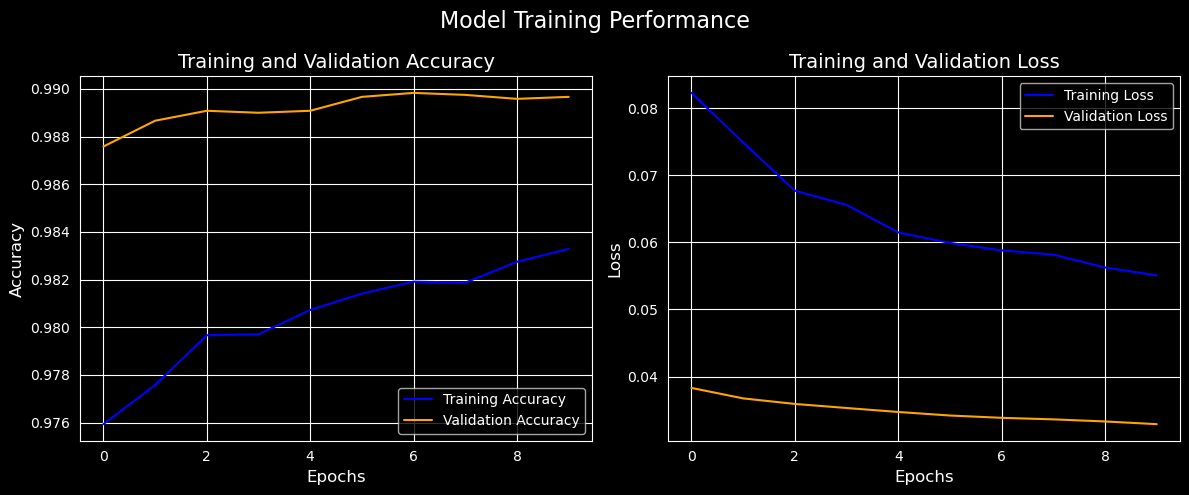

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mod.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(mod.history['val_accuracy'],
         label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(mod.history['loss'], label='Training Loss', color='blue')
plt.plot(mod.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)

plt.suptitle("Model Training Performance", fontsize=16)
plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import precision_score

# Get predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Calculate precision
precision = precision_score(y_test, y_pred_classes, average='weighted')
print(f'Precision: {precision:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 556us/step
Precision: 0.9875


In [18]:
from tensorflow.keras.callbacks import TensorBoard
import datetime

# Create a log directory for TensorBoard
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Train the model with TensorBoard callback
model.fit(datagen.flow(x_train, y_train, batch_size=32),
          epochs=100,
          validation_data=(x_test, y_test),
          callbacks=[early_stop, tensorboard_callback])




Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9595 - loss: 0.1366 - val_accuracy: 0.9856 - val_loss: 0.0476
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9597 - loss: 0.1336 - val_accuracy: 0.9832 - val_loss: 0.0526
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9594 - loss: 0.1344 - val_accuracy: 0.9868 - val_loss: 0.0403
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9600 - loss: 0.1323 - val_accuracy: 0.9849 - val_loss: 0.0495
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9600 - loss: 0.1332 - val_accuracy: 0.9838 - val_loss: 0.0501
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9620 - loss: 0.1303 - val_accuracy: 0.9856 - val_loss: 0.0449
